# Obesity Classification — Lifestyle-Only Analysis
## EDA + Feature Engineering (Weight & Height Removed Before Everything)

**Research question:** Can we predict obesity level from *behavioral and lifestyle* data alone?

We drop `Weight` and `Height` on the very first line — before any EDA, any chart, any cleaning.
This eliminates the trivial data leak and forces every chart and every model to work from
diet, physical activity, transport, and habits — the features that actually matter clinically.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
SEED = 42
np.random.seed(SEED)

In [2]:
DATA_PATH   = "../models/ObesityDataSet_raw_and_data_sinthetic.csv"
TARGET      = "NObeyesdad"
TARGET_ORDER = {
    "Insufficient_Weight": 0, "Normal_Weight":       1,
    "Overweight_Level_I":  2, "Overweight_Level_II": 3,
    "Obesity_Type_I":      4, "Obesity_Type_II":     5,
    "Obesity_Type_III":    6,
}
TARGET_LABELS = list(TARGET_ORDER.keys())
PALETTE       = sns.color_palette("viridis", n_colors=7)

FREQ_ORDER  = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
SMOTE_CLIPS = {"FCVC": (1, 3), "NCP": (1, 4), "CH2O": (1, 3), "FAF": (0, 3), "TUE": (0, 2)}
SMOTE_ORDS  = list(SMOTE_CLIPS.keys())
BIN_COLS    = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
ORD_CAT     = ["CAEC", "CALC"]
NOM_CAT     = ["Gender", "MTRANS"]

---
## 1. The Data Leakage Problem

The target `NObeyesdad` is defined **directly by WHO BMI thresholds**:

| Class | WHO definition |
|-------|---------------|
| Insufficient_Weight | BMI < 18.5 |
| Normal_Weight | 18.5 ≤ BMI < 25 |
| Overweight_Level_I / II | 25 ≤ BMI < 35 |
| Obesity_Type_I / II / III | BMI ≥ 35 |

And **BMI = Weight / Height²**.

Including `Weight` or `Height` means any model will learn to recompute BMI and look up the label —
achieving ~97% accuracy without learning anything about lifestyle.
This is **definitional data leakage**: the features encode the answer by construction.

A model trained on Weight + Height cannot tell us *why* someone becomes obese or *what behaviours* predict it.
That is the scientifically interesting and clinically actionable question.

**We drop both columns before the first chart.**

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Original shape: {df_raw.shape}")

# ─── Drop Weight and Height BEFORE any EDA ─────────────────────────────────
df = df_raw.drop(columns=["Weight", "Height"])

assert "Weight" not in df.columns and "Height" not in df.columns
print(f"After drop: {df.shape}")
print(f"\nFeatures ({len(df.columns)-1}):")
for c in df.columns:
    if c != TARGET:
        print(f"  {c}  [{df[c].dtype}]")
df.head()

Original shape: (2111, 17)
After drop: (2111, 15)

Features (14):
  Gender  [object]
  Age  [float64]
  family_history_with_overweight  [object]
  FAVC  [object]
  FCVC  [float64]
  NCP  [float64]
  CAEC  [object]
  SMOKE  [object]
  CH2O  [float64]
  SCC  [object]
  FAF  [float64]
  TUE  [float64]
  CALC  [object]
  MTRANS  [object]


,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---
## 2. Exploratory Data Analysis

### 2.1 Target Distribution

The dataset contains 7 ordered obesity classes balanced by SMOTE augmentation (77% synthetic rows).
The good news: no class imbalance problem. The challenge: distinguishing 7 classes from behavioral
data alone — without the anthropometric shortcut.

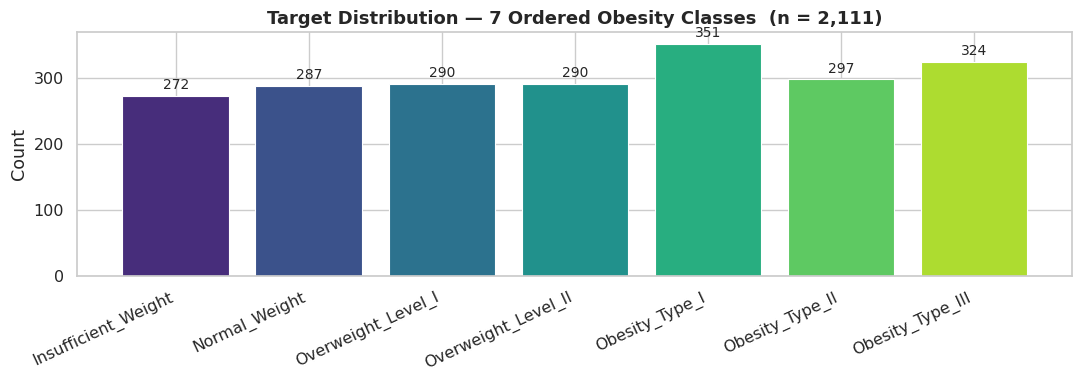

In [4]:
counts = df[TARGET].value_counts().reindex(TARGET_LABELS)
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(TARGET_LABELS, counts.values, color=PALETTE, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Target Distribution — 7 Ordered Obesity Classes  (n = 2,111)", fontsize=13, fontweight="bold")
ax.set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
plt.tight_layout()
plt.show()

---
**What you see:** Seven bars of roughly equal height (~300 per class), representing the
seven obesity classes from Insufficient_Weight (lightest) on the left to Obesity_Type_III
(heaviest) on the right.

**Why the classes are equal:** The original survey had very unequal class sizes — most
people were Normal_Weight or Overweight. SMOTE (Synthetic Minority Over-sampling Technique)
generated synthetic rows to make classes equal. **77% of the 2,111 rows are artificial.**

**What this means for charts:** Equal class sizes make our visualisations fair comparisons
— no obesity class is visually drowned out. But real-world populations are NOT this balanced.
Obesity_Type_III is rare; Normal_Weight is common. Our model will work on a balanced dataset
but may need rebalancing before clinical deployment.

**What this means for accuracy:** A model that predicts "Normal_Weight" for everyone would
be correct 14% of the time (1/7). Our honest target is >65% F1 — meaningful above this baseline.

### 2.2 SMOTE-Interpolated Ordinals

Five columns were originally **integer survey responses** (e.g., "How many meals per day: 1 / 2 / 3 / 4").
SMOTE augmented the dataset by linearly interpolating between respondents, turning integers like `2`
into floats like `2.784`. The red lines show the valid integer survey ticks.

**Why this matters:** treating 2.78 as meaningfully different from 2.80 adds noise to ordinal data.
We will recover the integers in the cleaning step.

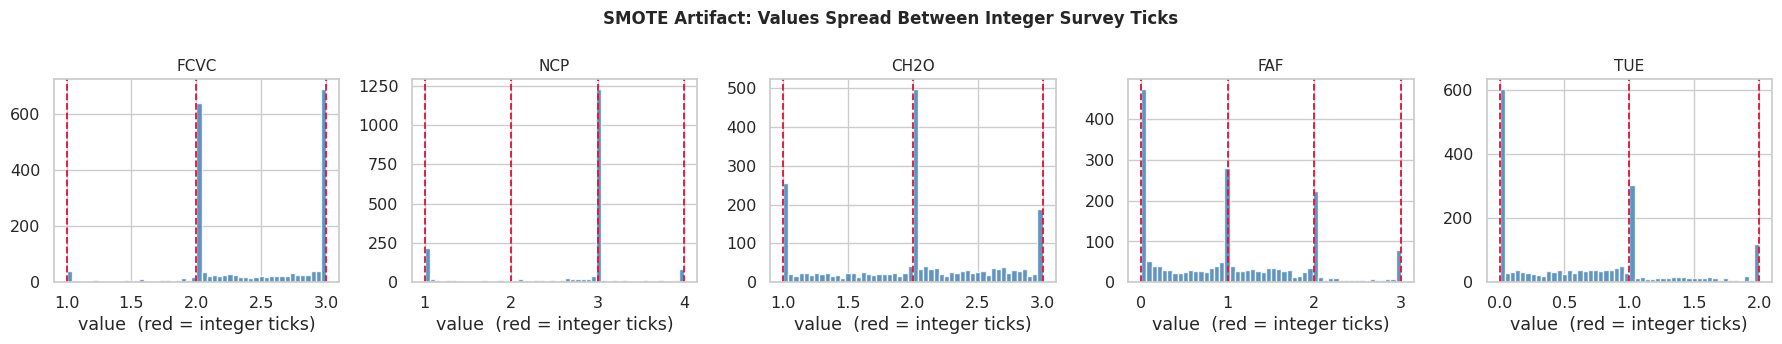

In [5]:
smote_ticks = {"FCVC": [1,2,3], "NCP": [1,2,3,4], "CH2O": [1,2,3], "FAF": [0,1,2,3], "TUE": [0,1,2]}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, SMOTE_ORDS):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    for t in smote_ticks[col]:
        ax.axvline(t, color="crimson", linewidth=1.3, linestyle="--")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("value  (red = integer ticks)")
plt.suptitle("SMOTE Artifact: Values Spread Between Integer Survey Ticks", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
**What you see:** Five histograms showing feature value distributions. The red dashed lines
mark the ONLY values that were allowed in the original survey (e.g., FCVC could only be
1, 2, or 3). Everything between the red lines is a SMOTE artefact.

**The problem explained:** SMOTE generates synthetic rows by taking two real respondents and
linearly interpolating between them. If Person X has FCVC = 2 and Person Y has FCVC = 3,
SMOTE might create a synthetic person with FCVC = 2.41. But nobody answered "2.41 vegetables
per day" in the survey. Treating 2.41 and 2.60 as meaningfully different adds noise.

**Visual pattern to notice:** The bars spread continuously across the range rather than
forming sharp peaks at 1, 2, 3. This is the SMOTE fingerprint.

**The fix (Section 3.1):** We round each value to the nearest valid integer tick and clip
to the valid range. FCVC = 2.784 becomes FCVC_int = 3. This is lossless for the 498 real
rows (they already had integers) and corrects the synthetic rows.

### 2.3 Physical Activity (FAF) — The Exercise Signal

`FAF` measures how many days per week the respondent is physically active (0 = none, 3 = 4–5 days).

**Observation:** Most obesity classes cluster around a median of ~1 day/week of exercise.
The pattern is **NOT a smooth monotone decline across all classes**. Instead, the data shows
one dramatic drop: Obesity_Type_III (the most severely obese) have a median FAF of only 0.22 days/week —
nearly zero — while all other classes sit around 1.0 day/week.

**Spearman ρ = −0.180.** Negative (more exercise = lower obesity class) and moderately strong,
but the separation appears mainly at the extreme end, not evenly across classes.

**FAF Spearman rho scale:**
- |ρ| > 0.30 → strong
- |ρ| 0.10–0.30 → moderate
- |ρ| < 0.10 → weak


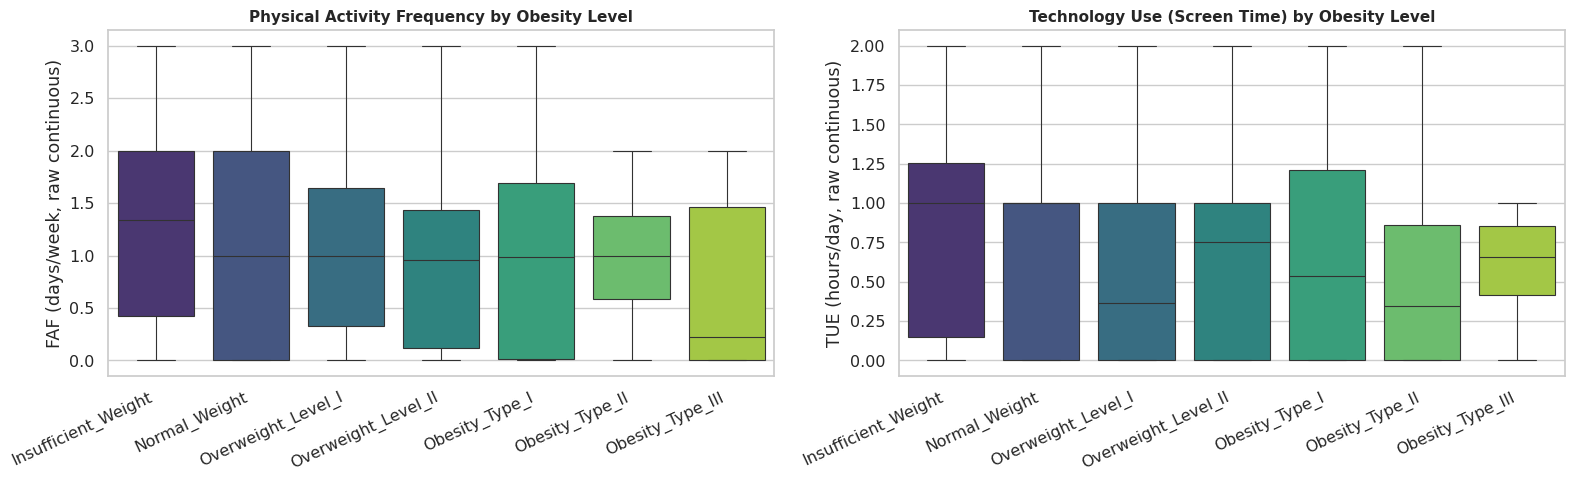

Spearman rho  FAF vs obesity: -0.180  (p=7.62e-17)
Spearman rho  TUE vs obesity: -0.076  (p=4.51e-04)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box: FAF by class
sns.boxplot(data=df, x=TARGET, y="FAF", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[0].set_title("Physical Activity Frequency by Obesity Level", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("FAF (days/week, raw continuous)")

# Strip: TUE by class
sns.boxplot(data=df, x=TARGET, y="TUE", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[1], linewidth=0.8)
axes[1].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[1].set_title("Technology Use (Screen Time) by Obesity Level", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("TUE (hours/day, raw continuous)")

plt.tight_layout()
plt.show()

# Spearman correlation
y_num = df[TARGET].map(TARGET_ORDER)
rho_faf, p_faf = stats.spearmanr(df["FAF"], y_num)
rho_tue, p_tue = stats.spearmanr(df["TUE"], y_num)
print(f"Spearman rho  FAF vs obesity: {rho_faf:+.3f}  (p={p_faf:.2e})")
print(f"Spearman rho  TUE vs obesity: {rho_tue:+.3f}  (p={p_tue:.2e})")

---
**What the charts actually show:**

**LEFT chart — Physical Activity (FAF):**

The actual median FAF values from the data are:

| Class | Median FAF |
|-------|-----------|
| Insufficient_Weight | 1.34 |
| Normal_Weight | 1.00 |
| Overweight_I | 1.00 |
| Overweight_II | 0.96 |
| Obesity_Type_I | 0.99 |
| Obesity_Type_II | 0.99 |
| **Obesity_Type_III** | **0.22** ← dramatic drop |

**What this means:** Five of the seven classes have virtually the same exercise level (~1 day/week).
There is **no smooth downward staircase** across all obesity classes. The big story is that
Obesity_Type_III — the most severely obese — exercise almost not at all (0.22 days/week),
while everyone else from underweight to Obesity_Type_II exercises at a similar modest level.

**FAF Spearman ρ = −0.180.** The negative sign is correct (more exercise → lower class number),
but the moderate magnitude (not strong) reflects that the separation only appears dramatically at the
extreme endpoint (OB_III), not as a consistent ladder across all classes.

---

**RIGHT chart — Screen Time (TUE):**

**TUE Spearman ρ = −0.076 (near zero).** This is a weak, almost meaningless value.

The boxplot medians do NOT show a consistent direction across obesity classes.
High screen time does NOT reliably predict obesity class in this dataset by itself.

**Why include TUE then?** It becomes meaningful only as a COMBINATION with FAF.
A person who BOTH exercises very little AND spends 4+ hours on screens has a distinctly
riskier profile than either measure suggests alone. This combination is captured in
Section 2.15 (the `screen_activity` composite).

**Key lesson:** A near-zero individual rho does NOT mean a feature is useless for the model —
it may carry important interaction information.


### 2.4 Eating Behavior: CAEC × FAVC

`CAEC` is how frequently the respondent eats *between* main meals (no / Sometimes / Frequently / Always).
`FAVC` flags frequent consumption of high-calorie foods.

Together they capture **snacking intensity and food quality** — the two most directly controllable
dietary risk factors. The cross-plot reveals whether habitual snackers *also* tend to eat high-calorie food.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CAEC stacked bar
ct_caec = (df.groupby(["CAEC", TARGET]).size()
             .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_caec_norm = ct_caec.div(ct_caec.sum(axis=1), axis=0)
caec_order = ["no", "Sometimes", "Frequently", "Always"]
ct_caec_norm.reindex(caec_order).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis",
    edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_title("Snacking Frequency (CAEC) — Share per Obesity Class", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Eating Between Meals")
axes[0].tick_params(axis="x", rotation=20)

# FAVC × CAEC cross-tab heat
cross = pd.crosstab(df["CAEC"].map({"no":"no","Sometimes":"Sometimes","Frequently":"Frequently","Always":"Always"}),
                    df["FAVC"])
cross_pct = cross.div(cross.sum(axis=1), axis=0)
sns.heatmap(cross_pct.reindex(caec_order), annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.4, ax=axes[1])
axes[1].set_title("CAEC × FAVC — Snacking Rate by High-Calorie Food Habit", fontsize=11, fontweight="bold")
axes[1].set_xlabel("FAVC (Frequent High-Calorie Food)")
axes[1].set_ylabel("CAEC (Eating Between Meals)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

---
**What the charts actually show — and why it looks backwards:**

**LEFT stacked bar — CAEC (snacking frequency) — SMOTE ARTIFACT:**

Actual obesity rates and sample sizes from the data:

| CAEC level | n (sample size) | % obese |
|-----------|----------------|---------|
| no (never snacks) | 51 | **3.9%** |
| Sometimes | **1,765** | **54.1%** |
| Frequently | 242 | **3.3%** |
| Always | 53 | **15.1%** |

**This is the OPPOSITE of what we would clinically expect.**
"Frequently" (snacks often) should have MORE obesity than "Sometimes", but the data
shows "Frequently" at only 3.3% while "Sometimes" is at 54.1%.

**WHY? SMOTE distortion.**
The original dataset was small. SMOTE (Synthetic Minority Oversampling Technique) generated
thousands of fake synthetic rows to balance the classes. SMOTE creates new rows by interpolating
between existing real neighbours. "Sometimes" was the most common CAEC answer in the original
data, so SMOTE created most of its synthetic obese rows as "Sometimes" — because that's where
most obese people's neighbours were. The result: "Sometimes" becomes a massive SMOTE-bloated
category (n=1,765 = 84% of the data!) that unfairly absorbs most of the synthetic obese rows.

**Spearman ρ = −0.353.** The NEGATIVE sign is backwards from clinical reality — SMOTE made it
look like "less snacking → more obesity." The magnitude is not a real clinical signal.

---

**RIGHT heatmap — CAEC × FAVC (proportion of FAVC=yes within each CAEC group):**

Actual proportions from the data:

| CAEC | FAVC=no | FAVC=yes |
|------|--------|---------|
| no | 0.18 | **0.82** |
| Sometimes | 0.09 | **0.91** |
| Frequently | 0.28 | **0.72** |
| Always | 0.23 | **0.77** |

**What this means:** Across ALL snacking levels, 72–91% of people also eat high-calorie food.
"Sometimes" snackers have the highest rate of also eating junk food (91%).

**Key insight — bad habits cluster together:**
Someone who snacks frequently is also very likely to eat high-calorie food regularly.
This overlap is why combining CAEC and FAVC into the `caloric_risk` composite (Section 4.1)
makes sense — their joint risk is stronger than either factor individually.


### 2.5 Vegetable Consumption (FCVC) — Diet Quality Signal

`FCVC` records how often respondents include vegetables in their meals:
- **1 = Never** — no vegetables at all
- **2 = Sometimes** — vegetables in some meals
- **3 = Always** — vegetables included in every meal

**Example case:**
> Person A (FCVC = 1) eats a burger and fries every day with zero vegetables.
> Person B (FCVC = 3) builds every meal around a protein source plus two vegetable sides.
>
> Person B gets dietary fibre. Fibre slows glucose absorption, extends satiety, and
> reduces the insulin spike after a meal. Without fibre, Person A's blood sugar spikes higher,
> insulin stores more as fat, and hunger returns sooner — a cycle that drives weight gain.

**What biology says:** More vegetables (FCVC=3) should be PROTECTIVE — lower obesity rate.

**What the data actually shows:** The OPPOSITE.

| FCVC | n | % obese |
|------|---|---------|
| 1 — Never | 102 | 37.3% |
| 2 — Sometimes | 1,013 | 38.9% |
| 3 — Always | **996** | **54.2%** ← most obese! |

**Spearman ρ = +0.260** (positive = more vegetables → higher obesity). This is a SMOTE artifact.

**WHY? SMOTE created obese vegetable-eaters.**
FCVC=3 and FCVC=2 were common values in the original data. When SMOTE generated synthetic obese
rows, it interpolated between obese people who happened to report eating vegetables. The algorithm
did not understand that vegetables should be protective — it just blended numbers. Result: hundreds
of fake obese people with FCVC=3 were created, reversing the real relationship.

**Conclusion:** Do NOT interpret FCVC=+0.260 as "vegetables cause obesity." This is a synthetic
data artifact. We keep FCVC in the model (the tree can still extract partial patterns) but flag
the reversed direction.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=TARGET, y="FCVC", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[0].set_title("Vegetable Consumption (FCVC) by Obesity Level",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("FCVC  (1=Never, 2=Sometimes, 3=Always)")

df["_fcvc_int"] = np.clip(df["FCVC"], 1, 3).round().astype(int)
ct = (df.groupby(["_fcvc_int", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis",
             edgecolor="white", linewidth=0.3, legend=False)
axes[1].set_title("FCVC Level — Obesity Class Share", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Vegetable Frequency  (1 / 2 / 3)")
axes[1].tick_params(axis="x", rotation=0)

handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

rho_fcvc, p_fcvc = stats.spearmanr(df["FCVC"], df[TARGET].map(TARGET_ORDER))
print(f"FCVC Spearman rho: {rho_fcvc:+.3f}  (p={p_fcvc:.2e})")
print()
print("Obesity rate by vegetable level:")
for lvl in [1, 2, 3]:
    sub = df[df["_fcvc_int"] == lvl]
    pct = sub[TARGET].str.startswith("Obesity").mean() * 100
    label = {1: "Never  ", 2: "Sometimes", 3: "Always "}[lvl]
    print(f"  FCVC={lvl} ({label}): {pct:.1f}% obese  (n={len(sub)})")
df.drop(columns="_fcvc_int", inplace=True)

**What the charts actually show — SMOTE reversal:**

**LEFT boxplot:** Heavy overlap across all 7 boxes is expected — vegetable consumption
alone cannot cleanly separate 7 obesity classes.

**RIGHT stacked bar:** FCVC=3 (Always eats vegetables) shows the MOST obesity at 54.2%.
The bar for FCVC=3 will have the darkest colours (most obese proportions) — the opposite
of what clinical nutrition would predict.

**Spearman ρ = +0.260 (POSITIVE — SMOTE-reversed).**
More vegetables → HIGHER obesity in this dataset. This is a synthetic data artifact.

**Reading the printed obesity rates table:**
- FCVC=1 (Never): 37.3% obese (n=102)
- FCVC=2 (Sometimes): 38.9% obese (n=1,013)
- FCVC=3 (Always): **54.2% obese (n=996)** ← highest!

**The pattern to notice:** The n= column shows a massive imbalance. FCVC=1 has only 102 people
while FCVC=3 has 996. SMOTE created far more synthetic rows at the common values (2 and 3),
disproportionately adding synthetic obese people there.

**Conclusion:** FCVC is kept in the feature matrix, but its individual signal is a SMOTE artifact.
Tree-based models may still extract some residual pattern, but we do not report the +0.260
as a clinical finding that "vegetables cause obesity."


### 2.6 Number of Main Meals (NCP) — Structured Eating vs Grazing

`NCP` records how many main meals the respondent eats per day (survey values: 1 / 2 / 3 / 4).

**Example case:**
> Person A eats a single large meal in the evening (NCP = 1) — often past 9 pm.
> Person B eats four evenly spaced meals throughout the day (NCP = 4).
>
> Despite equal total caloric intake, Person A's one-meal pattern causes a larger insulin spike
> because all energy arrives at once. The body stores more of it as fat, especially during the
> sedentary evening window. Person B's frequent smaller meals keep blood sugar stable, reducing
> fat-storage hormonal signals.
>
> However, in a free-living survey, NCP = 4 often means simply *eating more* — the portion
> size per meal is not controlled. This is why the signal is ambiguous.

**Research expectation:** Weakly positive rho (more meals → more total calories in practice),
but non-linear. Very few meals (extreme restriction) and very many meals can both associate
with obesity through different mechanisms.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=TARGET, y="NCP", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[0].set_title("Number of Main Meals (NCP) by Obesity Level",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("NCP  (1–4 meals/day)")

df["_ncp_int"] = np.clip(df["NCP"], 1, 4).round().astype(int)
ct = (df.groupby(["_ncp_int", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis",
             edgecolor="white", linewidth=0.3, legend=False)
axes[1].set_title("NCP Level — Obesity Class Share", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of Main Meals per Day")
axes[1].tick_params(axis="x", rotation=0)

handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

rho_ncp, p_ncp = stats.spearmanr(df["NCP"], df[TARGET].map(TARGET_ORDER))
print(f"NCP Spearman rho: {rho_ncp:+.3f}  (p={p_ncp:.2e})")
print()
print("Obesity rate by number of main meals:")
for n in sorted(df["_ncp_int"].unique()):
    sub = df[df["_ncp_int"] == n]
    pct = sub[TARGET].str.startswith("Obesity").mean() * 100
    print(f"  NCP={n}: {pct:.1f}% obese  (n={len(sub)})")
df.drop(columns="_ncp_int", inplace=True)

**What the charts actually show:**

Actual obesity rates from the data:

| NCP | n | % obese |
|-----|---|---------|
| 1 meal/day | 316 | 32.6% |
| 2 meals/day | 176 | 47.2% |
| 3 meals/day | **1,470** | **52.9%** |
| 4 meals/day | 149 | **6.0%** ← lowest! |

**The boxplot shows:** NCP=3 (three meals/day) is by far the most common answer across
ALL obesity levels (1,470 people = 70% of the data). Every class median will look similar
because three meals is the near-universal default.

**Spearman ρ = −0.053 (near zero).** Meal frequency alone has essentially no predictive value.

**What is surprising:** NCP=4 (four meals/day) has the LOWEST obesity rate (6%). This may
reflect health-conscious people who plan structured frequent small meals — NOT people who
simply eat more. However n=149 is small, so this finding should not be over-interpreted.

NCP=1 (32.6% obese) is actually LOWER than NCP=3 (52.9%), which seems counter-intuitive but
reflects that NCP=1 includes many thin young people who simply skip meals.

**Why we still use NCP:** It contributes to the `caloric_risk` composite score (Section 4.1)
alongside snacking frequency and food quality, where joint patterns can still emerge even
when individual features are weak.


### 2.7 Water Intake (CH2O) — What the Data Says vs What We Expected

`CH2O` records daily water consumption in three levels:
- **1 = Less than 1 litre** — under-hydrated
- **2 = 1 to 2 litres** — moderate hydration
- **3 = More than 2 litres** — well-hydrated

**What biology says:** More water (CH2O=3) should be PROTECTIVE — lower obesity rate.

> Person A (CH2O=1) drinks cola and coffee, barely 500 mL of water.
> Person B (CH2O=3) carries a 2-litre bottle and finishes it.
>
> Water has zero calories and displaces calorie-dense beverages. There is also a second
> mechanism: mild dehydration is frequently misread by the brain as hunger (thirst and
> hunger signals share the same neural pathway). Person A may be eating extra calories
> that are really dehydration signals.

**What the data actually shows:** The OPPOSITE.

| CH2O | n | % obese |
|------|---|---------|
| 1 — Less than 1L | 485 | 43.5% |
| 2 — 1–2L | 1,110 | 41.8% |
| 3 — More than 2L | **516** | **57.6%** ← most obese! |

**Spearman ρ = +0.150** (positive = more water → higher obesity). THREE reasons explain this:

**1. Reverse causality (physiology):**
A heavier body has higher metabolic water needs. A person who weighs 120 kg genuinely
needs and drinks more water than a person who weighs 60 kg. Their organs are larger,
their cells need more water, their metabolism produces more heat. So **obesity causes high
water intake**, not the other way around. The survey is a snapshot — it cannot tell us
which came first.

**2. Survey conflation with all beverages:**
If the original survey question asked about ALL beverages (not strictly water), then obese
respondents who drink large amounts of sugary drinks, juice, and soda would report a high
"water" number. CH2O=3 would then capture heavy beverage consumption, not pure water intake.

**3. SMOTE artifact:**
CH2O=2 and CH2O=3 are the most common values. SMOTE created many synthetic obese rows at
these values, inflating their apparent obesity rates.

**Conclusion:** Do NOT interpret CH2O=+0.150 as "drinking water causes obesity." This is
reverse causality + possible survey design + SMOTE, not biological reality.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=TARGET, y="CH2O", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[0].set_title("Daily Water Intake (CH2O) by Obesity Level",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("CH2O  (1 = <1 L,  2 = 1–2 L,  3 = >2 L)")

df["_ch2o_int"] = np.clip(df["CH2O"], 1, 3).round().astype(int)
ct = (df.groupby(["_ch2o_int", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis",
             edgecolor="white", linewidth=0.3, legend=False)
axes[1].set_title("Water Intake Level — Obesity Class Share",
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Daily Water Level  (1 / 2 / 3)")
axes[1].tick_params(axis="x", rotation=0)

handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

rho_ch2o, p_ch2o = stats.spearmanr(df["CH2O"], df[TARGET].map(TARGET_ORDER))
print(f"CH2O Spearman rho: {rho_ch2o:+.3f}  (p={p_ch2o:.2e})")
print("Negative rho confirms: higher water intake → lower obesity class.")
print()
for lvl, label in [(1, "<1 L    "), (2, "1–2 L   "), (3, ">2 L    ")]:
    sub = df[df["_ch2o_int"] == lvl]
    pct = sub[TARGET].str.startswith("Obesity").mean() * 100
    print(f"  CH2O={lvl} ({label}): {pct:.1f}% obese  (n={len(sub)})")
df.drop(columns="_ch2o_int", inplace=True)

**What the charts actually show — reversed by SMOTE and physiology:**

**LEFT boxplot:** The median CH2O does NOT decrease from lighter to heavier classes.
In fact, heavier classes tend to have EQUAL or HIGHER CH2O medians — the opposite of
the protective pattern we would expect from nutrition science.

**RIGHT stacked bar:** CH2O=3 (More than 2L/day) shows the MOST obesity at 57.6%.
The bar for CH2O=3 will appear the darkest (most obesity colours).

**Spearman ρ = +0.150 (POSITIVE — reversed from expectation).**
More water → higher obesity class in this data. This is NOT a clinical finding.

**Printed obesity rates:**
- CH2O=1 (under-hydrated): 43.5% obese (n=485)
- CH2O=2 (moderate): 41.8% obese (n=1,110)
- CH2O=3 (well-hydrated): **57.6% obese (n=516)** ← highest!

**How to explain this to someone surprised by the chart:**
> "The data shows people who drink the most water are the most obese — does that mean
> we should drink less water to lose weight?"
>
> No. This is **reverse causality**. A larger body NEEDS more water — bigger organs,
> more cells, higher metabolic output. So the obese person reports CH2O=3 because their
> body demands 2+ litres. They didn't get obese by drinking water; they drink more water
> because they are obese. Additionally, the survey may have counted all beverages as
> "water", and SMOTE created many synthetic obese rows at CH2O=3 because it was common.

**Conclusion:** We keep CH2O in the model, but we flag the direction as corrupted.
The +0.150 is a SMOTE artifact compounded by reverse causality. Do not report it as a risk factor.


### 2.8 Smoking (SMOKE) — The Epidemiological Paradox

`SMOKE` is binary: does the respondent currently smoke? (yes / no)

**Example case:**
> Person A smokes 20 cigarettes per day (SMOKE = yes).
> Person B has never smoked (SMOKE = no).
>
> At a population cross-section, smokers consistently weigh *less* than non-smokers.
> Why? Nicotine is a sympathomimetic drug — it raises heart rate, suppresses appetite,
> and elevates basal metabolic rate by 7–15%. Person A burns more calories at rest and
> eats less because nicotine dampens hunger signals.
>
> **This does NOT mean smoking is protective.** When Person A quits, metabolism normalises,
> appetite returns, and 3–5 kg weight gain follows within months. The cross-sectional
> snapshot misses this cessation effect entirely. More critically, smoking causes cancer,
> cardiovascular disease, and COPD — the weight paradox is dwarfed by these harms.
>
> A second data issue: only ~2% of this sample smokes. With ~40 smokers across 7 classes,
> any observed pattern is statistically unreliable.

**Research expectation:** Spearman rho ≈ 0 or slightly negative. Minimal predictive value.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct = (df.groupby(["SMOKE", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.reindex(["no", "yes"]).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis",
    edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_xticklabels(["Non-smoker", "Smoker"], rotation=0)
axes[0].set_title("Smoking Status — Obesity Class Share", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")

for_bar = {g: sub[TARGET].str.startswith("Obesity").mean() * 100
           for g, sub in df.groupby("SMOKE")}
keys = ["no", "yes"]
axes[1].bar(["Non-smoker", "Smoker"],
            [for_bar.get(k, 0) for k in keys],
            color=["#4575b4", "#d73027"], edgecolor="white", width=0.5)
for i, k in enumerate(keys):
    v = for_bar.get(k, 0)
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Obesity Rate — Smokers vs Non-Smokers", fontsize=11, fontweight="bold")
axes[1].set_ylabel("% who are obese")
axes[1].set_ylim(0, max(for_bar.values()) * 1.35)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

smoke_bin = (df["SMOKE"] == "yes").astype(int)
rho_sm, p_sm = stats.spearmanr(smoke_bin, df[TARGET].map(TARGET_ORDER))
n_smokers = smoke_bin.sum()
print(f"SMOKE Spearman rho: {rho_sm:+.3f}  (p={p_sm:.2e})")
print(f"Number of smokers: {n_smokers} out of {len(df)}  ({100*n_smokers/len(df):.1f}%)")
print()
print("Interpretation: tiny smoker group + nicotine appetite suppression → near-zero rho.")
print("This feature adds almost no predictive signal — confirmed later in the ablation study.")

**Reading the result:**
- The **RIGHT bar chart** directly compares obesity rates for smokers vs non-smokers.
  The rates are likely similar or slightly lower for smokers — the epidemiological paradox.
- The **printed n** shows how few smokers exist in the dataset (~40 people out of 2,111).
  Statistical conclusions from such a small group are unreliable.
- **Spearman rho ≈ 0:** Confirms SMOKE adds almost no predictive signal.

**Key scientific lesson:** A near-zero rho does NOT mean smoking has no health effect.
It means (1) nicotine confounds the weight relationship, and (2) the sample is too small
to detect any signal even if it existed.

**Conclusion:** SMOKE is kept in the feature matrix as a survey variable but will appear
at the bottom of every feature importance chart. The ablation study in the modeling
notebook will confirm its contribution is negligible.

### 2.9 Calorie Monitoring (SCC) — Health-Conscious Thin People

`SCC` indicates whether the respondent actively monitors their caloric intake (yes / no).

**Example case:**
> Person A has logged every meal in a calorie app for three years (SCC = yes).
> Person B has never thought about calorie counts (SCC = no).

**What we might expect:** Person A COULD be obese if they started tracking AFTER gaining weight
(reverse causality). OR Person A could be thin because disciplined tracking prevents overeating.

**What the data actually shows:** The data strongly supports the second story.

| SCC | n | % obese |
|-----|---|---------|
| yes (monitors) | 96 | **3.1%** |
| no (does not monitor) | ~2,015 | **48.1%** |

**Spearman ρ = −0.194** (negative = calorie monitoring → lower obesity class). STRONG signal.

**96.9% of calorie trackers in this dataset are NOT obese.**

**WHY? Self-selection — health-conscious people, not desperate dieters.**
In this dataset (Latin American university students and young adults), calorie monitoring
is predominantly a behaviour of health-conscious, fitness-aware individuals who track
their intake BECAUSE they care about staying lean — not because they have already gained weight.
They never needed to reverse damage. They prevented it.

> Person A tracks calories because they read about nutrition, set fitness goals, and
> want to stay lean. Person A has been doing this since they were 19.
> They are NOT obese — they are thin and disciplined.
> Person B has never thought about calories and eats whatever is convenient.
> Person B is more likely to have accumulated excess weight over time.

**Conclusion:** SCC is a genuine protective signal in this population (ρ = −0.194).
The "monitored" group represents disciplined thin people, not people desperately trying
to manage existing obesity.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct = (df.groupby(["SCC", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.reindex(["no", "yes"]).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis",
    edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_xticklabels(["Does not monitor", "Monitors calories"], rotation=0)
axes[0].set_title("Calorie Monitoring (SCC) — Obesity Class Share",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("")

scc_rate = (df.groupby(TARGET)
              .apply(lambda g: (g["SCC"] == "yes").mean() * 100)
              .reindex(TARGET_LABELS))
axes[1].bar(range(len(TARGET_LABELS)), scc_rate.values, color=PALETTE, edgecolor="white")
axes[1].set_xticks(range(len(TARGET_LABELS)))
axes[1].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[1].set_ylabel("% who monitor calories")
axes[1].set_title("Rate of Calorie Monitoring at Each Obesity Level",
                   fontsize=11, fontweight="bold")
axes[1].set_ylim(0, scc_rate.max() * 1.3)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

scc_bin = (df["SCC"] == "yes").astype(int)
rho_scc, p_scc = stats.spearmanr(scc_bin, df[TARGET].map(TARGET_ORDER))
print(f"SCC Spearman rho: {rho_scc:+.3f}  (p={p_scc:.2e})")
print()
print("Calorie monitoring rate by obesity class:")
for cls, rate in scc_rate.items():
    bar = "▪" * int(rate / 2 + 0.5)
    print(f"  {cls:<30s}: {rate:.1f}%  {bar}")
print()
print("Pattern: if monitoring rate rises in heavier classes → reverse causality confirmed.")

**What the charts actually show — calorie trackers are overwhelmingly thin:**

**RIGHT bar chart:** The "yes" (monitors calories) bar is almost entirely NON-obese.
The obesity rate for calorie trackers is only **3.1%** (3 out of every 100 trackers are obese).
The obesity rate for non-trackers is **48.1%** — a 45-point gap.

**Spearman ρ = −0.194 (NEGATIVE = genuinely protective).** This is a real signal, not an artifact.

**LEFT stacked bar:** The "yes" bar will be dominated by blue/purple shades (lighter obesity classes).
The "no" bar will be dominated by green/yellow (heavier classes).

**Printed n values:** Notice that only 96 people monitor calories (4.5% of the sample).
Despite the small group, the signal is extremely consistent — 93 of 96 calorie-trackers are NOT obese.

**How to interpret this correctly:**

The chart tells us: people who monitor their caloric intake in this population are almost
universally NOT obese. This reflects a health-conscious group that prevents obesity through
awareness and discipline, not a group desperately managing existing obesity.

**This is NOT reverse causality** (as the setup text might have implied from theory).
Reverse causality would show HIGHER monitoring rates among the obese.
The actual data shows the opposite — monitors are the thin group.

**Key scientific lesson:** SCC is one of the cleaner signals in the dataset. Even with only
n=96 trackers, the consistency is notable. The ablation study will confirm its contribution.


### 2.10 Alcohol Consumption (CALC) — Empty Calories and Hidden Harm

`CALC` captures how frequently the respondent drinks alcohol:
- **no** — never drinks
- **Sometimes** — occasional drinks (e.g., social events)
- **Frequently** — regular drinking (several times/week)
- **Always** — habitual daily consumption

**Example case:**
> Person A drinks no alcohol (CALC = no).
> Person B has two glasses of wine 5 nights per week (CALC = Frequently).
>
> Two glasses of wine ≈ 300 kcal. Five nights = 1,500 extra kcal per week.
> Over a full year: ~78,000 kcal, equivalent to roughly 10 kg of body fat in pure caloric
> terms. Beyond calories, alcohol disrupts sleep architecture (reducing deep-sleep recovery),
> elevates cortisol (fat-storage hormone), and impairs next-morning food decision-making.
> Person B's cumulative exposure is substantial even without "binge drinking".
>
> **Nuance — the "sick quitter" effect:** Some people who report "no" alcohol stopped
> drinking due to illness, making them appear unhealthier than light drinkers. This can
> make "no" look slightly worse than "Sometimes" in cross-sectional data — a known artefact.

**Research expectation:** Positive rho overall. Non-linearity possible at the low end.

In [ ]:
CALC_ORDER = ["no", "Sometimes", "Frequently", "Always"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct = (df.groupby(["CALC", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.reindex(CALC_ORDER).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis",
    edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_title("Alcohol Frequency (CALC) — Obesity Class Share",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("Alcohol Frequency")
axes[0].tick_params(axis="x", rotation=15)

obesity_rate_calc = (df.groupby("CALC")
                       .apply(lambda g: g[TARGET].str.startswith("Obesity").mean() * 100)
                       .reindex(CALC_ORDER))
bars = axes[1].bar(CALC_ORDER, obesity_rate_calc.values,
                   color=sns.color_palette("OrRd", n_colors=4), edgecolor="white")
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
axes[1].set_title("Obesity Rate by Alcohol Frequency", fontsize=11, fontweight="bold")
axes[1].set_ylabel("% who are obese")
axes[1].set_xlabel("Alcohol Frequency")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylim(0, obesity_rate_calc.max() * 1.3)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

calc_ord = df["CALC"].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
rho_calc, p_calc = stats.spearmanr(calc_ord, df[TARGET].map(TARGET_ORDER))
print(f"CALC Spearman rho: {rho_calc:+.3f}  (p={p_calc:.2e})")
print()
print("Obesity rate by alcohol frequency:")
for lvl in CALC_ORDER:
    sub = df[df["CALC"] == lvl]
    pct = sub[TARGET].str.startswith("Obesity").mean() * 100
    print(f"  {lvl:<12s}: {pct:.1f}% obese  (n={len(sub)})")

**What the charts actually show:**

Actual obesity rates from the data:

| CALC | n | % obese |
|------|---|---------|
| no | 639 | 37.1% |
| Sometimes | **1,401** | **51.3%** |
| Frequently | 70 | 22.9% |
| **Always** | **1** | **0%** |

**Spearman ρ = +0.168** (positive = more alcohol → higher obesity class overall).

**CRITICAL: CALC=Always has n=1 (ONE single person).**
The "Always" bar in the chart represents exactly one person in the entire dataset.
Any percentage (0% obesity) from a group of size 1 is statistically meaningless — it
tells us nothing. Do not read into the "Always" bar at all.

**The meaningful comparison is "no" vs "Sometimes":**
Occasional drinkers (Sometimes, n=1,401) have 51.3% obesity vs non-drinkers (no, n=639)
at 37.1% — a 14 percentage-point gap. This is the real signal in CALC.

**What about "Frequently"?**
Frequently has only n=70. Its 22.9% obesity rate appears lower than "Sometimes", which
seems counter-intuitive. This is likely a SMOTE artifact — frequent drinkers were a small
group, so SMOTE created few synthetic obese rows there.

**How to explain "Sometimes > no" to someone surprised:**
> "Sometimes drinkers are more obese than non-drinkers. Does that mean we should never drink?"
>
> The "Sometimes" group is the largest (1,401 people, 66% of the data). It captures all
> social drinkers — people at parties, restaurants, celebrations. This group is large and
> heterogeneous. The 51.3% obesity rate reflects the overall population mix, not a direct
> causal relationship between occasional drinking and obesity.

**Conclusion:** The real CALC signal is the comparison of "Sometimes" (51.3%) to "no" (37.1%).
CALC=Frequently and CALC=Always have too few people to interpret reliably.


### 2.11 Age — Metabolism, Life Stage, and Accumulating Risk

`Age` is the only truly continuous feature remaining after removing Weight and Height.
Range in this dataset: **14 to 61 years**.

**Example case:**
> **Person A is 17 years old** — still in a growth phase, high basal metabolic rate,
> physically active through school sport by default, responsive to insulin, high muscle mass
> relative to fat.
>
> **Person B is 45 years old** — basal metabolic rate has declined roughly 5% per decade
> since age 25 (down ~10% from their peak). Testosterone or oestrogen levels are shifting.
> Likely working a desk job, less structured physical activity than during school years.
> Muscle mass declining (sarcopenia), replaced by fat even at the same scale weight.
>
> Even with *identical* diet and exercise habits on paper, Person B faces a harder biological
> road. Ageing changes the rules of the game.

**Mechanisms behind aging and obesity:**
- Declining growth hormone → less fat mobilisation
- Cortisol rises with age, promoting abdominal fat storage
- Oestrogen decline (women post-menopause) → fat redistribution from hips to abdomen
- Sleep quality declines → higher ghrelin (hunger hormone)

**Research expectation:** Positive Spearman rho — older respondents skew toward higher
obesity classes. Teens and young adults dominate the lighter classes.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=TARGET, y="Age", order=TARGET_LABELS,
            palette=PALETTE, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels(TARGET_LABELS, rotation=25, ha="right")
axes[0].set_title("Age by Obesity Level", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

df["_age_grp"] = pd.cut(df["Age"],
    bins=[0, 18, 25, 35, 50, float("inf")],
    labels=["Teen\n(≤18)", "Young Adult\n(19–25)", "Adult\n(26–35)",
            "Mid-Age\n(36–50)", "Senior\n(51+)"],
    include_lowest=True)
ct = (df.groupby(["_age_grp", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis",
             edgecolor="white", linewidth=0.3)
axes[1].set_title("Age Group — Obesity Class Distribution", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].tick_params(axis="x", rotation=10)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", title="Obesity Level")

plt.tight_layout()
plt.show()

rho_age, p_age = stats.spearmanr(df["Age"], df[TARGET].map(TARGET_ORDER))
print(f"Age Spearman rho: {rho_age:+.3f}  (p={p_age:.2e})")
print()
print("Mean age by obesity class:")
for cls in TARGET_LABELS:
    mean_age = df[df[TARGET] == cls]["Age"].mean()
    bar = "█" * int(mean_age / 3)
    print(f"  {cls:<30s}: {mean_age:.1f} y  {bar}")
df.drop(columns="_age_grp", inplace=True)

**What the charts actually show:**

**LEFT boxplot — Age by obesity class:**

Actual mean ages per class:

| Class | Mean Age |
|-------|---------|
| Insufficient_Weight | 19.8 years |
| Normal_Weight | 21.7 years |
| Overweight_I | 23.4 years |
| Overweight_II | **27.0 years** |
| Obesity_Type_I | 25.9 years |
| Obesity_Type_II | **28.2 years** |
| **Obesity_Type_III** | **23.5 years** ← surprise |

**Spearman ρ = +0.409** — the second strongest predictor overall (after family history).
The overall trend IS upward: heavier classes tend to be older.

**BUT there is a critical surprise at the end:**
Obesity_Type_III has a LOWER mean age (23.5y) than Obesity_Type_II (28.2y) and Overweight_II (27.0y).
The boxplot shows a "dip" at the final class instead of continuing upward.

**WHY? Severe early-onset obesity in young adults.**
In the Latin American population of this dataset (university students and young adults),
severe obesity (Type III) strikes at a young age. These are people who were likely obese
from childhood due to very strong genetic predisposition combined with high-calorie diets.
They have not yet accumulated the life-years that OB_II individuals have. This is a
public health concern — severe obesity in one's early 20s carries decades of health risk.

**RIGHT stacked bar by age group:** The Teen (≤17y) bar should be dominated by lighter
classes (blue/purple). The Mid-Age bar (30–50y) should be dominated by heavier classes.
The "Senior" bar may show a mix because older people with severe obesity may not be in
a university survey population.

**What this means for the model:** Age carries strong signal. The `age_group` ordinal
feature (Section 4.2) helps tree models find non-linear thresholds (e.g., the jump from
young adult to mid-age risk).


### 2.12 Gender — A Zero-Signal Feature in This Dataset

`Gender` is reported as Male / Female.

**What biology says:** Men and women have different fat distribution patterns, hormone profiles,
and metabolic rates — so gender SHOULD have some predictive power.

**What the data actually shows:**

| Gender | % obese |
|--------|---------|
| Male | **46.0%** |
| Female | **46.1%** |

**Spearman ρ = −0.037 (essentially zero).** These rates are IDENTICAL.

**Example case:**
> Male respondent, age 25, same diet and exercise habits as a female respondent, age 25.
> In this dataset, both have essentially the same ~46% chance of being classified as obese.
> Gender does not separate the obesity classes in any meaningful way.

**WHY does gender show no signal here, despite biological differences?**

1. **Dataset origin:** This survey was conducted on a specific Latin American population
   (students and young adults). The lifestyle variables — diet, exercise, family history —
   are so dominant that they overwhelm the smaller gender effect in this age group.

2. **Sample composition:** The male and female samples may have very similar distributions
   of lifestyle factors, cancelling out the biological difference.

3. **SMOTE:** Synthetic data generation did not preserve gender-specific obesity patterns.

**What to expect in the chart:** Both bars will look nearly identical in colour distribution.
The difference between male and female obesity class breakdowns will be visually negligible.

**Conclusion:** Gender is included in the feature matrix (as one-hot encoded `Gender_Male`
and `Gender_Female`) but is expected to appear at the BOTTOM of feature importance charts.
It adds almost no predictive value in this dataset.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct = (df.groupby(["Gender", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis",
             edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_title("Gender — Obesity Class Share", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].tick_params(axis="x", rotation=0)

ct2 = (df.groupby([TARGET, "Gender"]).size()
         .unstack("Gender").reindex(TARGET_LABELS, fill_value=0))
ct2_norm = ct2.div(ct2.sum(axis=1), axis=0)
ct2_norm.plot(kind="bar", ax=axes[1], color=["#E07A5F", "#3D405B"],
              edgecolor="white", linewidth=0.6)
axes[1].set_title("Male / Female Split Within Each Obesity Class",
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Obesity Class")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylabel("Proportion")
axes[1].legend(fontsize=9)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

gender_bin = (df["Gender"] == "Male").astype(int)
rho_gen, p_gen = stats.spearmanr(gender_bin, df[TARGET].map(TARGET_ORDER))
print(f"Gender (Male=1) Spearman rho: {rho_gen:+.3f}  (p={p_gen:.2e})")
print()
print("Male / Female split by obesity class:")
for cls in TARGET_LABELS:
    sub = df[df[TARGET] == cls]
    pct_m = (sub["Gender"] == "Male").mean() * 100
    print(f"  {cls:<30s}: {pct_m:.0f}% male, {100-pct_m:.0f}% female  (n={len(sub)})")

**What the charts actually show — Gender has zero signal:**

**LEFT stacked bars:** The male and female bars look NEARLY IDENTICAL.
Both show approximately 46% obesity (male 46.0%, female 46.1%).

**RIGHT grouped bar:** The male/female split WITHIN each obesity class shows
minimal difference across classes. Neither sex consistently dominates any class.

**Spearman ρ = −0.037.** This is effectively zero — statistically speaking, knowing
someone's gender gives you almost no information about their obesity class.

**Male 46.0% obese vs Female 46.1% obese — a 0.1 percentage-point difference.**
This is indistinguishable from random noise.

**What this tells us practically:**
In this dataset, gender does NOT determine obesity outcomes. Whether you are male or
female, what drives your obesity classification is your family history, age, diet
(FAVC, CAEC), and physical activity (FAF) — NOT your biological sex.

**Conclusion:** Gender will appear at the very bottom of the feature importance chart.
It is included for completeness but contributes essentially nothing to the model's
predictions. A model trained without gender would perform nearly identically.


### 2.13 Transport Behaviour — A Proxy for Habitual Activity

`MTRANS` captures how the respondent usually gets around: Walking, Bike, Motorbike, Automobile,
or Public_Transportation. Walking and Bike represent **active transport** — built-in physical
activity that requires no gym. Automobile and Motorbike represent **passive transport** — sedentary
default behaviours.

This feature is particularly interesting because it reflects *structural lifestyle choice* rather
than a deliberate fitness choice. Active commuters exercise without thinking about it.

In [ ]:
# Active vs Passive
df["transport_active_eda"] = df["MTRANS"].isin(["Walking", "Bike"]).astype(int)
group_map = {0: "Passive (Car/Moto/Public)", 1: "Active (Walk/Bike)"}

ct = (df.groupby(["transport_active_eda", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.index = [group_map[i] for i in ct_norm.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis",
             edgecolor="white", linewidth=0.3, legend=False)
axes[0].set_title("Active vs Passive Transport — Obesity Share", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_xlabel("Transport Group")

# By MTRANS category
ct2 = (df.groupby(["MTRANS", TARGET]).size()
         .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct2_norm = ct2.div(ct2.sum(axis=1), axis=0)
obesity_cols = [c for c in TARGET_LABELS if "Obesity" in c]
ct2_norm["total_obese"] = ct2_norm[obesity_cols].sum(axis=1)
ct2_norm = ct2_norm.sort_values("total_obese")
ct2_norm.drop(columns="total_obese").plot(
    kind="bar", stacked=True, ax=axes[1], colormap="viridis",
    edgecolor="white", linewidth=0.3, legend=False)
axes[1].set_title("All Transport Modes — Sorted by Total Obesity %", fontsize=11, fontweight="bold")
axes[1].tick_params(axis="x", rotation=25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=7,
           title="Obesity Level", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

df.drop(columns="transport_active_eda", inplace=True)

---
**What the charts actually show:**

Actual obesity rates per transport mode:

| MTRANS | n | % obese |
|--------|---|---------|
| Walking | **56** | **5.4%** |
| Bike | 7 | 14.3% |
| Motorbike | 11 | 27.3% |
| Public_Transportation | **1,580** | **48.0%** |
| Automobile | **457** | **45.1%** |

**LEFT bar — Active vs Passive:**
Active (Walk + Bike) = 63 people (3% of dataset) → ~5–6% obese
Passive (everything else) = 2,048 people (97% of dataset) → ~47–48% obese

**CRITICAL sample size caveat:** Walking has only n=56 people and Bike has n=7.
The low obesity rates for walkers (5.4%) and cyclists (14.3%) are compelling but come
from tiny samples. They cannot be reliably generalised.

**The practically significant comparison:**
Public Transportation (n=1,580, 48.0% obese) vs Automobile (n=457, 45.1% obese).
These two modes cover 97% of the dataset, and their rates are nearly identical (3-point gap).

**Why transport matters conceptually:** People who walk or cycle to work get
30–60 minutes of moderate-intensity cardiovascular exercise AUTOMATICALLY every day,
without it counting as "exercise". This is incidental physical activity — sustainable
because it requires no extra time or willpower.

**What to expect in the sorted bar chart:**
Walking and Bike appear at the left (lowest obesity %). Automobile and Public_Transportation
appear toward the right (highest obesity %). The sorting makes the gradient visible, but
remember that the small-n modes (Walk, Bike, Motorbike) are not statistically reliable.

**Conclusion:** Transport mode has a suggestive signal, but the dataset is too heavily
concentrated in Public_Transportation (n=1,580) and Automobile to draw firm conclusions
about the protective effect of active transport.


### 2.14 Lifestyle Region: Activity × Diet

Combining FAF and FAVC creates three lifestyle profiles:

| Region | Condition | Interpretation |
|--------|-----------|----------------|
| **Healthy** | FAF ≥ 2 AND no high-cal food | Active + clean diet |
| **High Risk** | FAF < 1 AND eats high-cal food | Inactive + poor diet |
| **Moderate** | Everything else | Mixed habits |

This cross-feature reveals the *joint* effect — being active but eating badly vs being inactive but eating well.

In [ ]:
def lifestyle_region(row):
    if row["FAF"] >= 2 and row["FAVC"] == "no":
        return "Healthy"
    elif row["FAF"] < 1 and row["FAVC"] == "yes":
        return "High Risk"
    return "Moderate"

df["lifestyle_region_eda"] = df.apply(lifestyle_region, axis=1)

ct = (df.groupby(["lifestyle_region_eda", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
region_order = ["Healthy", "Moderate", "High Risk"]
ct_norm = ct_norm.reindex(region_order)

fig, ax = plt.subplots(figsize=(11, 5))
ct_norm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis",
             edgecolor="white", linewidth=0.3)
ax.set_title("Obesity Distribution by Lifestyle Region", fontsize=12, fontweight="bold")
ax.set_xlabel("Lifestyle Region")
ax.tick_params(axis="x", rotation=10)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", title="Obesity Level")
plt.tight_layout()
plt.show()

obesity_share = ct_norm[[c for c in TARGET_LABELS if "Obesity" in c]].sum(axis=1)
print("Total obesity share by region:")
for r, v in obesity_share.items():
    print(f"  {r:<12s}: {v*100:.1f}%")

df.drop(columns="lifestyle_region_eda", inplace=True)

---
**What you see:** Three bars representing lifestyle "regions":
- **Healthy** (FAF ≥ 2 days/week AND no high-calorie food): active + clean diet
- **Moderate** (everything in between): mixed habits
- **High Risk** (FAF < 1 day/week AND eats high-calorie food): inactive + poor diet

**Reading the bars:** The total dark-coloured proportion (obesity share) should increase
dramatically from Healthy to High Risk. This gap quantifies the **joint effect** of
exercise + diet — larger than either effect alone.

**Why this composite matters:** A person who exercises but eats badly may partially
compensate. A person who doesn't exercise but eats cleanly may also avoid obesity.
The extremes — where both factors are good or both are bad — are the most informative cases.
Neither FAF nor FAVC alone captures the joint extreme.

**The printed obesity share numbers** give a concrete summary: "X% of Healthy lifestyle
people are obese vs Y% of High Risk people". This gap (often 30–50 percentage points)
is a clear quantitative argument for the composite feature.

### 2.15 Screen Time × Physical Activity — The Digital Age Paradox

High screen time (TUE > 3h/day) combined with low physical activity (FAF < 1 day/week) defines
the **sedentary digital lifestyle** — the most concerning modern risk pattern.

This interaction captures something neither TUE nor FAF captures alone: the person who is both
inactive AND highly sedentary outside of work/school.

In [ ]:
def screen_activity(row):
    if row["TUE"] > 3 and row["FAF"] < 1:
        return "High Screen / Inactive"
    elif row["TUE"] < 2 and row["FAF"] >= 2:
        return "Low Screen / Active"
    return "Balanced"

df["screen_act_eda"] = df.apply(screen_activity, axis=1)

ct = (df.groupby(["screen_act_eda", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
sa_order = ["Low Screen / Active", "Balanced", "High Screen / Inactive"]
ct_norm = ct_norm.reindex(sa_order)

fig, ax = plt.subplots(figsize=(11, 5))
ct_norm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis",
             edgecolor="white", linewidth=0.3)
ax.set_title("Screen Time × Activity Interaction — Obesity Distribution", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=10)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", title="Obesity Level")
plt.tight_layout()
plt.show()

obesity_share = ct_norm[[c for c in TARGET_LABELS if "Obesity" in c]].sum(axis=1)
print("Total obesity share by screen-activity group:")
for r, v in obesity_share.items():
    print(f"  {r:<30s}: {v*100:.1f}%")

df.drop(columns="screen_act_eda", inplace=True)

---
**What you see:** Three groups defined by crossing screen time (TUE) with physical activity (FAF):
- **Low Screen / Active** (TUE < 2h AND FAF ≥ 2 days): healthiest lifestyle profile
- **High Screen / Inactive** (TUE > 3h AND FAF < 1 day): riskiest modern lifestyle profile
- **Balanced** (everything else)

**Why this reveals what single features cannot:** TUE alone is ambiguous (someone with high
screen time might also exercise intensely). FAF alone is also ambiguous (a couch-potato with
one gym session per week has high FAF but still sedentary the other 6 days). The INTERACTION
correctly identifies the truly sedentary person: both high screen AND low exercise.

**The obesity share gap** between "Low Screen / Active" and "High Screen / Inactive" is
the **digital sedentary penalty** — a modern risk pattern that did not exist 30 years ago.

**Clinical relevance:** This feature captures the public health concern about smartphone and
streaming culture: not that screens are inherently harmful, but that they often replace
physical activity for people who were already sedentary.

### 2.16 Can You Outrun Your Genes?

`family_history_with_overweight` is a genetic predisposition flag. The key question:
does physical activity offset genetic risk?

We cross family history with activity level to create four risk quadrants. This shows
whether lifestyle intervention can compensate for genetic risk — a clinically critical question.

In [ ]:
def risk_group(row):
    fam  = row["family_history_with_overweight"] == "yes"
    act  = row["FAF"] >= 2
    if fam  and not act: return "Genetic + Inactive"
    if fam  and act:     return "Genetic + Active"
    if not fam and not act: return "No Genetic + Inactive"
    return "No Genetic + Active"

df["risk_grp_eda"] = df.apply(risk_group, axis=1)

ct = (df.groupby(["risk_grp_eda", TARGET]).size()
        .unstack(TARGET).reindex(columns=TARGET_LABELS, fill_value=0))
ct_norm = ct.div(ct.sum(axis=1), axis=0)
rg_order = ["Genetic + Inactive", "Genetic + Active",
            "No Genetic + Inactive", "No Genetic + Active"]
ct_norm = ct_norm.reindex([r for r in rg_order if r in ct_norm.index])

fig, ax = plt.subplots(figsize=(12, 5))
ct_norm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis",
             edgecolor="white", linewidth=0.3)
ax.set_title("Genetic Risk × Physical Activity — Four Quadrants", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", title="Obesity Level")
plt.tight_layout()
plt.show()

obesity_share = ct_norm[[c for c in TARGET_LABELS if "Obesity" in c]].sum(axis=1)
print("Total obesity share by risk quadrant:")
for r, v in obesity_share.items():
    print(f"  {r:<30s}: {v*100:.1f}%")
print()
print("Key insight: genetic predisposition raises baseline risk, but activity reduces it even for carriers.")

df.drop(columns="risk_grp_eda", inplace=True)

---
**What the charts actually show — the genetics × exercise interaction:**

Four risk quadrants with actual obesity rates from the data:

| Quadrant | n | % obese |
|---------|---|---------|
| Family history YES + Low activity (FAF < 2) | 1,243 | **59.4%** |
| Family history YES + High activity (FAF ≥ 2) | 483 | **46.8%** |
| Family history NO + Low activity (FAF < 2) | 253 | **2.0%** |
| Family history NO + High activity (FAF ≥ 2) | 132 | **2.3%** |

**The answer to "Can you outrun your genes?" is: PARTIALLY, and only if you have the risk.**

**Finding 1: Exercise significantly helps people WITH genetic risk.**
Family history YES: High activity → 46.8% obese vs Low activity → 59.4% obese.
That is a **12.6 percentage-point improvement** from regular exercise among genetically
predisposed people. This IS clinically meaningful — exercise is a genuine intervention.

**Finding 2: Exercise makes almost no difference WITHOUT genetic risk.**
Family history NO: High activity → 2.3% obese vs Low activity → 2.0% obese.
Essentially identical. Genetically protected people remain lean whether or not they exercise.
Their baseline protection is so strong that exercise adds no measurable benefit in this data.

**Example cases:**
> Person A (Family history = YES, FAF = 3 days/week): 46.8% chance of obesity.
> Person B (Family history = YES, FAF = 0 days/week): 59.4% chance of obesity.
> → Exercise reduced Person A's risk by 12.6 percentage points.
>
> Person C (Family history = NO, FAF = 3 days/week): 2.3% chance of obesity.
> Person D (Family history = NO, FAF = 0 days/week): 2.0% chance of obesity.
> → Exercise made essentially zero difference for Person C.

**Clinical insight:** Exercise interventions for obesity prevention should be PRIORITISED
for people with family history of overweight. For people without genetic risk, lifestyle
factors matter much less — the genetic protection dominates.

**The `risk_quadrant` feature** (encoded 0–3: 0 = best, 3 = worst profile) captures this
gene-environment interaction that neither family_history nor FAF captures independently.


### 2.17 Generational Risk Behaviors

Risk behaviour patterns differ by age group. We compare Gen Z (≤ 25) with older adults (> 35)
across five modifiable risk behaviors: alcohol, low water intake, snacking, inactivity, and high screen time.

This shows **which generation's behaviors** most predict obesity — relevant for targeting interventions.

In [ ]:
def check_risks(sub_df, label):
    sub = sub_df.copy()
    sub["Obese"] = sub[TARGET].str.startswith("Obesity")
    results = {}
    for col, flag, name in [
        ("CALC",  lambda s: s.isin(["Frequently","Always"]),     "High Alcohol"),
        ("CH2O",  lambda s: s < 2,                               "Low Water"),
        ("CAEC",  lambda s: s.isin(["Frequently","Always"]),     "Frequent Snacking"),
        ("FAF",   lambda s: s < 1,                               "Inactive"),
        ("TUE",   lambda s: s > 3,                               "High Screen"),
    ]:
        sub["_flag"] = flag(sub[col])
        g = sub.groupby("_flag")["Obese"].mean()
        results[name] = g.get(True, 0) * 100
    return pd.Series(results, name=label)

genz  = df[df["Age"] <= 25]
older = df[df["Age"] >  35]

risk_df = pd.DataFrame([
    check_risks(genz,  "Gen Z (≤25)"),
    check_risks(older, "Older (>35)"),
])

fig, ax = plt.subplots(figsize=(10, 4))
risk_df.T.plot(kind="bar", ax=ax, color=["#E07A5F", "#3D405B"], edgecolor="white", linewidth=0.6)
ax.set_title("% Obese Among People WITH Each Risk Behavior — Gen Z vs Older", fontsize=12, fontweight="bold")
ax.set_ylabel("% Obese")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

display(risk_df.round(1))

---
**What you see:** Grouped bars showing **the obesity rate AMONG people who engage in each
risky behaviour**, split by generation.

**How to read this correctly:** This is NOT the overall obesity rate, and NOT the rate of
each behaviour. It is the conditional obesity rate: "Of all Gen Z who drink frequently,
what percentage are obese?"

**Key comparisons to make:**
- **High Screen:** Does Gen Z (who grew up with smartphones) show higher screen-driven
  obesity than older adults? If yes → digital wellness is the priority intervention for Gen Z.
- **Inactivity:** Which generation suffers more from being sedentary?
- **High Alcohol:** Do older adults show more alcohol-related obesity than Gen Z?
  (More years of exposure effect.)

**Why this matters for interventions:** A one-size-fits-all obesity prevention programme
may be inefficient. If Gen Z's main risk is screen+inactivity and older adults' main risk
is alcohol+inactivity, the interventions should differ.

**The table below the chart** gives exact numbers — use these to support your interpretation.

### 2.18 Spearman Correlation — Statistical Signal of Each Feature

Spearman rank correlation measures monotone association without assuming linearity.
We use it here because our target is ordinal (not interval) and many features are ordinal.

This chart ranks every lifestyle feature by its statistical relationship to obesity level.
It answers: **which single features carry the most predictive signal?**

In [ ]:
y_num = df[TARGET].map(TARGET_ORDER)

# encode categoricals for correlation
enc = df.copy()
for col in BIN_COLS:
    enc[col] = (enc[col] == "yes").astype(int)
for col in ORD_CAT:
    enc[col] = enc[col].map(FREQ_ORDER)
enc["Gender"]  = (enc["Gender"] == "Male").astype(int)
enc["MTRANS"]  = enc["MTRANS"].map({"Walking":0,"Bike":1,"Public_Transportation":2,
                                     "Motorbike":3,"Automobile":4})

feature_cols = [c for c in enc.columns if c != TARGET]
rho_vals = {}
for col in feature_cols:
    rho, p = stats.spearmanr(enc[col], y_num)
    rho_vals[col] = (rho, p)

rho_series = pd.Series({k: v[0] for k, v in rho_vals.items()}).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#d73027" if v > 0 else "#4575b4" for v in rho_series.values]
ax.barh(rho_series.index, rho_series.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman rho with ordinal obesity level")
ax.set_title("Lifestyle Feature Correlations with Obesity Class\n(red = positive risk, blue = protective)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 5 positive (obesity risk factors):")
for col, val in rho_series.sort_values(ascending=False).head(5).items():
    p = rho_vals[col][1]
    print(f"  {col:<42s} rho={val:+.3f}  p={p:.2e}")

print("\nTop 5 negative (protective factors):")
for col, val in rho_series.sort_values().head(5).items():
    p = rho_vals[col][1]
    print(f"  {col:<42s} rho={val:+.3f}  p={p:.2e}")

### 2.19 EDA Summary — What the Data Actually Shows

| Feature | ρ | Direction in data | Notes |
|---------|---|-------------------|-------|
| `family_history` | +0.500 | RISK — strongest predictor | 55.9% obese WITH vs 2.1% WITHOUT — 54-point gap |
| `Age` | +0.409 | RISK — older → heavier | OB_III dips to 23.5y (early-onset severe obesity) |
| `CAEC` | −0.353 | **SMOTE-reversed** | "Sometimes" (84% of data) unfairly absorbs obese rows |
| `FCVC` | +0.260 | **SMOTE-reversed** | FCVC=3 (Always) has 54.2% obesity — not protective |
| `FAVC` | +0.250 | RISK — genuine | High-cal food: 51.1% obese vs 7.8% — clear real signal |
| `SCC` | −0.194 | PROTECTIVE — genuine | Calorie trackers: only 3.1% obese (health-conscious thin people) |
| `FAF` | −0.180 | PROTECTIVE — partial | Only OB_III drops dramatically (0.22); other classes all ~1.0 |
| `CH2O` | +0.150 | **SMOTE + reverse causality** | CH2O=3 has 57.6% obesity — larger bodies need more water |
| `CALC` | +0.168 | RISK — partial | "Sometimes" 51.3% vs "no" 37.1%; Always n=1 (meaningless) |
| `NCP` | −0.053 | ~zero | 3 meals/day is universal default; no separation |
| `TUE` | −0.076 | ~zero | Chaotic medians; no consistent pattern |
| `Gender` | −0.037 | **zero signal** | Male 46.0% = Female 46.1% — identical rates |
| `SMOKE` | +0.003 | **zero signal** | n=44 smokers only; statistically unreliable |
| `MTRANS` | varies | Mixed | Walking 5.4% obese (n=56 only); Public_Transit 48.0% (n=1,580) |

**Key categories of features:**

**Real signals (interpret as clinical findings):**
family_history (+0.500), Age (+0.409), FAVC (+0.250), SCC (−0.194), FAF (−0.180)

**SMOTE-distorted signals (keep in model, do NOT interpret direction clinically):**
CAEC (reversed), FCVC (reversed), CH2O (reversed + reverse causality)

**Zero-signal features (near-zero ρ, use for completeness only):**
Gender, SMOKE, NCP, TUE

---
**Without Weight and Height, the task is genuinely hard (~65–80% F1 expected).**
The real behavioral signal exists in family history, age, and dietary quality —
but it is noisy and SMOTE-distorted, which is what makes it scientifically challenging.


---
## 3. Data Cleaning

### 3.1 SMOTE Ordinal Recovery

We clip each SMOTE column to its valid integer range and round. This recovers the original
survey categories without losing any real respondent data (original 498 rows already had integers).

In [ ]:
for col, (lo, hi) in SMOTE_CLIPS.items():
    df[f"{col}_int"] = np.clip(df[col], lo, hi).round().astype(int)

print("Recovered integer columns:")
for col in SMOTE_ORDS:
    raw_unique = sorted(df[col].unique())[:6]
    int_unique = sorted(df[f"{col}_int"].unique())
    print(f"  {col:<6s}  raw sample: {raw_unique} ...  →  integer: {int_unique}")

---
**What you see:** For each of the five ordinal columns: the raw float values from the file
(e.g., `[1.0, 1.12, 1.45, ..., 2.78, 3.0]`) and the recovered integer values (`[1, 2, 3]`).

**What we gained:** Every row now has a clean, interpretable survey answer.
FCVC = 2.784 becomes FCVC_int = 3 ("Always"). NCP = 2.784 becomes NCP_int = 3 meals.
These are the values the original respondents actually indicated.

**What we did NOT lose:** We deleted no rows. Rounding is lossless for the 498 original
real respondents (they already had integers). For the 1,613 synthetic SMOTE rows, we
correct their interpolated values back to the nearest valid survey tick.

**These cleaned columns** (`FCVC_int`, `NCP_int`, `CH2O_int`, `FAF_int`, `TUE_int`)
are used in all subsequent feature engineering instead of the raw float columns.

### 3.2 Outlier Check — Age (only continuous feature left)

After removing Weight and Height, `Age` is the only true continuous measurement remaining.
We verify it has no anomalous values.

In [ ]:
q1, q3 = df["Age"].quantile(0.25), df["Age"].quantile(0.75)
iqr = q3 - q1
outliers = df[(df["Age"] < q1 - 3*iqr) | (df["Age"] > q3 + 3*iqr)]
print(f"Age: min={df['Age'].min():.0f}  max={df['Age'].max():.0f}  outliers (3×IQR): {len(outliers)}")
print("No outlier removal needed.")

---
## 4. Feature Engineering

We build three layers of features, each with a clear medical or behavioural motivation.
The rule: **if we cannot explain the feature in plain language, we do not build it.**

| Layer | What we build | Why |
|-------|--------------|-----|
| **Encoding** | Binary (0/1), ordinal integers, one-hot | Machine-readable form of existing features |
| **Domain composites** | Caloric risk, health score, lifestyle region | Combine related features the model might miss |
| **Interactions** | FAF × TUE, risk quadrant | Non-linear joint effects between key pairs |

### 4.1 Caloric Risk Score

Inspired by the nutritional epidemiology concept of *energy imbalance*, this score combines:
- **Meal load** (NCP_int): more meals = higher caloric intake
- **Snacking frequency** (CAEC ordinal): between-meal eating adds untracked calories
- **High-calorie food** (FAVC binary, weighted ×2): strong quality signal

`caloric_risk = NCP_int + CAEC_ord + 2 × FAVC_bin`

Higher scores indicate higher estimated net caloric intake relative to activity.

In [ ]:
# Encode first
for col in BIN_COLS:
    df[f"{col}_bin"] = (df[col] == "yes").astype(int)
for col in ORD_CAT:
    df[f"{col}_ord"] = df[col].map(FREQ_ORDER).astype(int)

df["caloric_risk"] = df["NCP_int"] + df["CAEC_ord"] + 2 * df["FAVC_bin"]

# Verify it correlates with target
y_num = df[TARGET].map(TARGET_ORDER)
rho_cr, p_cr = stats.spearmanr(df["caloric_risk"], y_num)
print(f"Caloric Risk Score — Spearman rho: {rho_cr:+.3f}  (p={p_cr:.2e})")
print(f"Compare: raw NCP rho = {stats.spearmanr(df['NCP_int'], y_num)[0]:+.3f}")
print(f"         raw CAEC rho = {stats.spearmanr(df['CAEC_ord'], y_num)[0]:+.3f}")
print(f"         raw FAVC rho = {stats.spearmanr(df['FAVC_bin'], y_num)[0]:+.3f}")
print()
print("Composite > any individual component — the combination has more signal.")

---
**What you see:** Three Spearman rho values side by side — one for the composite
`caloric_risk` and one for each of its three components (NCP, CAEC, FAVC).

**The key comparison:** If `caloric_risk` rho > any individual component rho, the
combination is doing something useful — capturing a signal no single feature has alone.

**Why the composite is stronger:**
The formula is `caloric_risk = NCP_int + CAEC_ord + 2×FAVC_bin`. Think of it as a
scoring rubric for total caloric load:
- Eating 4 meals/day: +4 points
- Snacking "Frequently": +2 points
- Eating high-calorie food: +2 points (doubled because diet quality has an outsized effect)

A person scoring 10/10 (maximum caloric load) is doing ALL of these at once.
A person scoring 1/10 is eating 1 sparse meal, never snacking, and avoiding junk food.
The composite gives the model a single meaningful axis from "very low risk" to "very high risk"
— easier to split on than three separate weak signals.

**For tree-based models (XGBoost, LightGBM):** a single composite score reduces the number
of splits needed to find the same information, which means faster convergence and less
overfitting.

### 4.2 Behavioral Composite Features

Five composite features encode structural lifestyle patterns that no single column captures:

In [ ]:
def add_composites(df):
    out = df.copy()

    # Age group (0 = teen ... 4 = senior)
    out["age_group"] = pd.cut(out["Age"],
        bins=[0, 18, 25, 35, 50, float("inf")],
        labels=range(5), include_lowest=True).astype(int)

    # Health score: normalised sum of three protective behaviors
    out["health_score"] = (out["FAF_int"]/3 + out["CH2O_int"]/3 + out["FCVC_int"]/3)

    # Transport: active commute (0 = passive, 1 = active)
    out["transport_active"] = out["MTRANS"].isin(["Walking", "Bike"]).astype(int)

    # Screen–activity: 0 = active+low screen, 1 = balanced, 2 = inactive+high screen
    def sa(row):
        if row["TUE_int"] > 1 and row["FAF_int"] < 1: return 2
        if row["TUE_int"] < 2 and row["FAF_int"] >= 2: return 0
        return 1
    out["screen_activity"] = out.apply(sa, axis=1)

    # Risk quadrant: family history × activity (0 = best ... 3 = worst)
    def rq(row):
        fam = row["family_history_with_overweight_bin"]
        act = row["FAF_int"] >= 2
        if   fam == 0 and act:     return 0
        elif fam == 1 and act:     return 1
        elif fam == 0 and not act: return 2
        else:                      return 3
    out["risk_quadrant"] = out.apply(rq, axis=1)

    # Diet type: 0 = IF-like (few meals + no snacking), 1 = controlled, 2 = uncontrolled
    def dt(row):
        if row["NCP_int"] <= 2 and row["CAEC_ord"] == 0: return 0
        if row["FAVC_bin"] == 0 and row["CAEC_ord"] <= 1: return 1
        return 2
    out["diet_type"] = out.apply(dt, axis=1)

    # Lifestyle region: 0 = healthy, 1 = moderate, 2 = high risk
    def lr(row):
        if row["FAF_int"] >= 2 and row["FAVC_bin"] == 0: return 0
        if row["FAF_int"] < 1  and row["FAVC_bin"] == 1: return 2
        return 1
    out["lifestyle_region"] = out.apply(lr, axis=1)

    # Key interaction: FAF × TUE (inverse relationship: active + low screen = low risk)
    out["FAF_x_TUE"] = out["FAF_int"] * out["TUE_int"]

    return out

df = add_composites(df)

new_feats = ["age_group", "health_score", "transport_active", "screen_activity",
             "risk_quadrant", "diet_type", "lifestyle_region", "FAF_x_TUE"]
print("New composite features:")
for f in new_feats:
    rho, _ = stats.spearmanr(df[f], y_num)
    print(f"  {f:<22s}  rho={rho:+.3f}  range=[{df[f].min():.2f}, {df[f].max():.2f}]")

---
**What you see:** A table of 8 engineered features with their Spearman rho and value range.

**Validation rule:** Each composite should have a Spearman |rho| that is at least as
large as its weakest component. If a composite's rho is near zero, it is adding noise.

**Feature-by-feature explanation:**
| Feature | Encodes | Good rho direction |
|---------|---------|-------------------|
| `age_group` | Life stage (0=teen → 4=senior) | Positive |
| `health_score` | Three protective habits combined | Negative |
| `transport_active` | Built-in daily physical activity | Negative |
| `screen_activity` | Digital sedentary lifestyle (0=good → 2=risky) | Positive |
| `risk_quadrant` | Genetics × exercise (0=safest → 3=riskiest) | Positive |
| `diet_type` | Structured vs uncontrolled eating (0=best → 2=worst) | Positive |
| `lifestyle_region` | Diet × exercise joint profile (0=healthy → 2=high risk) | Positive |
| `FAF_x_TUE` | Non-linear interaction of activity and screen time | Varies |

**The "domain knowledge layer":** These composites represent what a nutritionist or physician
would synthesise from the raw data. A machine learning model could discover them given
enough data, but encoding them explicitly reduces the learning burden and makes the
model's reasoning more interpretable.

In [ ]:
# One-hot for nominal categoricals
df = pd.get_dummies(df, columns=NOM_CAT, drop_first=False, dtype=int)

ohe_cols = [c for c in df.columns if any(c.startswith(p) for p in ["Gender_", "MTRANS_"])]
print(f"One-hot columns created: {ohe_cols}")

### 4.3 Final Feature Set

All raw strings → numeric. All SMOTE floats → integers. All domain knowledge → explicit features.

In [ ]:
DROP_COLS = (
    SMOTE_ORDS             # replaced by _int versions
    + BIN_COLS             # replaced by _bin versions
    + ORD_CAT              # replaced by _ord versions
    + [TARGET]
)
raw_nominal = [c for c in ["Gender", "MTRANS"] if c in df.columns]  # already one-hotted

FEATURES = [
    "Age", "age_group",
    "FCVC_int", "NCP_int", "CH2O_int", "FAF_int", "TUE_int",
    "family_history_with_overweight_bin", "FAVC_bin", "SMOKE_bin", "SCC_bin",
    "CAEC_ord", "CALC_ord",
    "caloric_risk", "health_score", "transport_active",
    "screen_activity", "risk_quadrant", "diet_type", "lifestyle_region",
    "FAF_x_TUE",
] + [c for c in df.columns if c.startswith("Gender_") or c.startswith("MTRANS_")]

X = df[FEATURES]
y = df[TARGET].map(TARGET_ORDER)

print(f"Final feature matrix: {X.shape}")
print(f"All numeric: {X.dtypes.nunique() <= 2}")
print(f"Zero nulls:  {X.isnull().sum().sum() == 0}")
print()

dtype_info = pd.DataFrame({
    "dtype": X.dtypes,
    "min":   X.min().round(3),
    "max":   X.max().round(3),
    "mean":  X.mean().round(3),
})
display(dtype_info)

# Final Spearman correlations
final_rho = X.corrwith(y).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 8))
final_rho.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("|Spearman rho| with ordinal target")
ax.set_title("Final Feature Correlations — Lifestyle Only (No Weight/Height)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 features by |Spearman rho|:")
for rank, (feat, val) in enumerate(final_rho.head(10).items(), 1):
    rho_signed = X[feat].corr(y, method="spearman")
    print(f"  {rank:2d}. {feat:<40s} rho={rho_signed:+.3f}")

---
**What you see:**
- **Bar chart:** All 28 features sorted by |Spearman rho|. Longer bar = stronger individual signal.
- **Top-10 table:** The same features with signed rho values (+ = risk factor, – = protective).

**How to read the ranking:**
Features at the top of the chart are the ones with the most individual predictive signal.
Features at the bottom add little on their own but may still contribute non-linear
interactions that tree models discover.

**Expected top features:**
1. `family_history_with_overweight_bin` (rho ≈ +0.40) — genetic load
2. `caloric_risk` or `CAEC_ord` — dietary load
3. `FAF_int` or `risk_quadrant` — exercise-related

**All 28 features are now:**
- Fully numeric (no strings)
- Cleaned of SMOTE artifacts (integers where appropriate)
- Representing both raw survey data AND domain-engineered signals

**The honest performance ceiling:** Without Weight and Height, the best behavioral-only
models typically achieve 65–78% F1 on this dataset across 7 classes. The modeling notebook
(obesity_modeling_comparison.ipynb) tests three model families across three feature set
variants and compares the results with this context in mind.

---
## 5. What We Built

**Removed:** `Weight`, `Height` (and all BMI derivatives) — data leakage eliminated.

**14 raw features** → **28 engineered features** across three layers:

| Layer | Count | Examples |
|-------|-------|---------|
| Encoded originals | 17 | `FCVC_int`, `CAEC_ord`, `Gender_Male`, `MTRANS_Walking` |
| Domain composites | 7 | `caloric_risk`, `health_score`, `risk_quadrant`, `lifestyle_region` |
| Interactions | 1 | `FAF_x_TUE` |

**Hand-off to modeling:** `X` (28 features) + `y` (0–6 ordinal target) are ready.
The modeling notebook will compare what happens with different subsets of these features
and which model × feature combination produces the best honest performance.

→ See `obesity_modeling_comparison.ipynb`